<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Classwork/Trainers_notes/AI(Deep_Learning)/Fashion_MNIST_FNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Good Morning Everyone! 🌟

I hope all of you are doing great 😊
Thank you for joining today’s session.

📌 Agenda for Today:
We will be doing a hands-on practice session on Feedforward Neural Networks (FNNs).
It’s going to be interactive and practical, so get ready to explore and learn!

⏳ Please wait for few more minutes, and then we’ll begin the session.

Looking forward to an exciting learning experience together 🚀🔥

# Fashion Image Classification Using a Feedforward Neural Network (FNN)

## Problem Context

A retail company wants to automate product categorization using images. When a seller uploads a clothing item image, the system should be able to classify it into the correct category such as T-shirt, trouser, sneaker, coat, bag, etc.

To prototype this system, you will use the **Fashion-MNIST dataset**, which contains **60,000 training images** and **10,000 test images**, each belonging to one of **ten clothing categories**. Every image is **28×28 pixels in grayscale**.

Your task is to build a simple **Feedforward Neural Network (FNN)** model to classify the images correctly.

---

## Requirements

### 1. Load the dataset
Use the built-in Fashion-MNIST dataset from TensorFlow/Keras.

### 2. Preprocess the data
- Normalize pixel values between 0 and 1  
- Flatten each image from **28×28 → 784 features**

### 3. Build the model
Your model should include:

- Input layer with **784 neurons**
- At least **one hidden Dense layer** with an activation function (example: ReLU)
- Output layer with **10 neurons** and **softmax activation**

### 4. Train the model
Print:

- Training accuracy  

### 5. Test the model
Print:

- Test accuracy  



https://arxiv.org/pdf/1708.07747

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Data :", x_train.shape)
print("Training Labels:", y_train.shape)
print("Test Data:", x_test.shape)
print("Test Labels:", y_test.shape)


Training Data : (60000, 28, 28)
Training Labels: (60000,)
Test Data: (10000, 28, 28)
Test Labels: (10000,)


| Label (Numeric) | Actual Class |
| --------------- | ------------ |
| 0               | T-shirt/top  |
| 1               | Trouser      |
| 2               | Pullover     |
| 3               | Dress        |
| 4               | Coat         |
| 5               | Sandal       |
| 6               | Shirt        |
| 7               | Sneaker      |
| 8               | Bag          |
| 9               | Ankle boot   |


In [ ]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal"
"Shirt","Sneaker","Bag","Ankle boot"]

In [ ]:
#normalize

train_x = x_train/255.0
test_x =  x_test/255.0

In [ ]:
#flatten
train_x = train_x.reshape(-1,784)
test_x = test_x.reshape(-1,784)

In [ ]:
#model building
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation = "relu"),
    tf.keras.layers.Dense(10,activation = "softmax")

])

In [ ]:
#compile

model.compile(optimizer= "adam", loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])


In [ ]:
#train the model
model.fit(train_x,y_train,epochs = 5,batch_size= 128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8927 - loss: 0.3014
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8946 - loss: 0.2902
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8970 - loss: 0.2824
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9026 - loss: 0.2676
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9034 - loss: 0.2647


In [ ]:
#evaluate

loss, acc = model.evaluate(test_x,y_test,verbose = 1)
print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8836 - loss: 0.3306
0.8827999830245972


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
act SandalShirt
pred SandalShirt


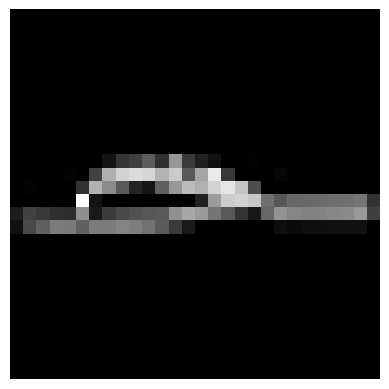

In [ ]:
i=8
img = test_x[i].reshape(28,28)
plt.imshow(img,cmap = "gray")
plt.axis("off")
pred = model.predict(test_x[i:i+1])
pred_label = int(np.argmax(pred[0]))

print("act", labels[int(y_test[i])])
print("pred", labels[pred_label])